# BrushCue Example: Dithering Effect

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/dithering_effect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/dithering-effect

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


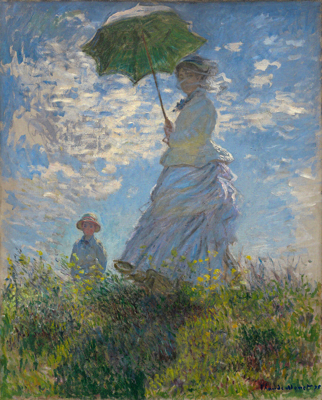

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
color_levels = 4
pattern_size = 1
strength = 1.0
graph = input_image.spacial_effect_shader(
    "let source = sample(position);\nlet x = i32(floor(position.x / pattern_size)) % 4;\nlet y = i32(floor(position.y / pattern_size)) % 4;\nlet threshold = (bayer4(x, y) / 16.0) - 0.5;\nlet steps = color_levels - 1.0;\nlet dithered = clamp(floor(source.rgb * steps + threshold + vec3f(0.5)) / steps, vec3f(0.0), vec3f(1.0));\nreturn vec4f(mix(source.rgb, dithered, strength), source.a);",
    "fn bayer4(x: i32, y: i32) -> f32 {\n  if (y == 0) { if (x == 0) { return 0.0; } if (x == 1) { return 8.0; } if (x == 2) { return 2.0; } return 10.0; }\n  if (y == 1) { if (x == 0) { return 12.0; } if (x == 1) { return 4.0; } if (x == 2) { return 14.0; } return 6.0; }\n  if (y == 2) { if (x == 0) { return 3.0; } if (x == 1) { return 11.0; } if (x == 2) { return 1.0; } return 9.0; }\n  if (x == 0) { return 15.0; } if (x == 1) { return 7.0; } if (x == 2) { return 13.0; } return 5.0;\n}",
    0.0,
    bc.Dictionary.create()
    .add("color_levels", bc.Int.to_float(color_levels))
    .add("pattern_size", bc.Int.to_float(pattern_size))
    .add("strength", strength),
    bc.ColorRepresentation.srgb(),
).crop(input_image.bounds())

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
